<a href="https://colab.research.google.com/github/ShubhanNA/India_nightlights_regression/blob/main/India_nightlights_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("python_electricity_nighlights.csv").dropna()
df.head()


,State,Year,Electricity_Consumption,Nightlights_Sum
11,Andhra Pradesh,2013,36078.8,1474568.626
12,Andhra Pradesh,2014,45309.0,1461682.678
13,Andhra Pradesh,2015,38940.5,1588227.073
14,Andhra Pradesh,2016,52821.0,1495493.154
15,Andhra Pradesh,2017,56227.4,1735182.474


In [ ]:
df_EPI =  df["Nightlights_Sum"] / df["Electricity_Consumption"]
df["EPI"] = df_EPI


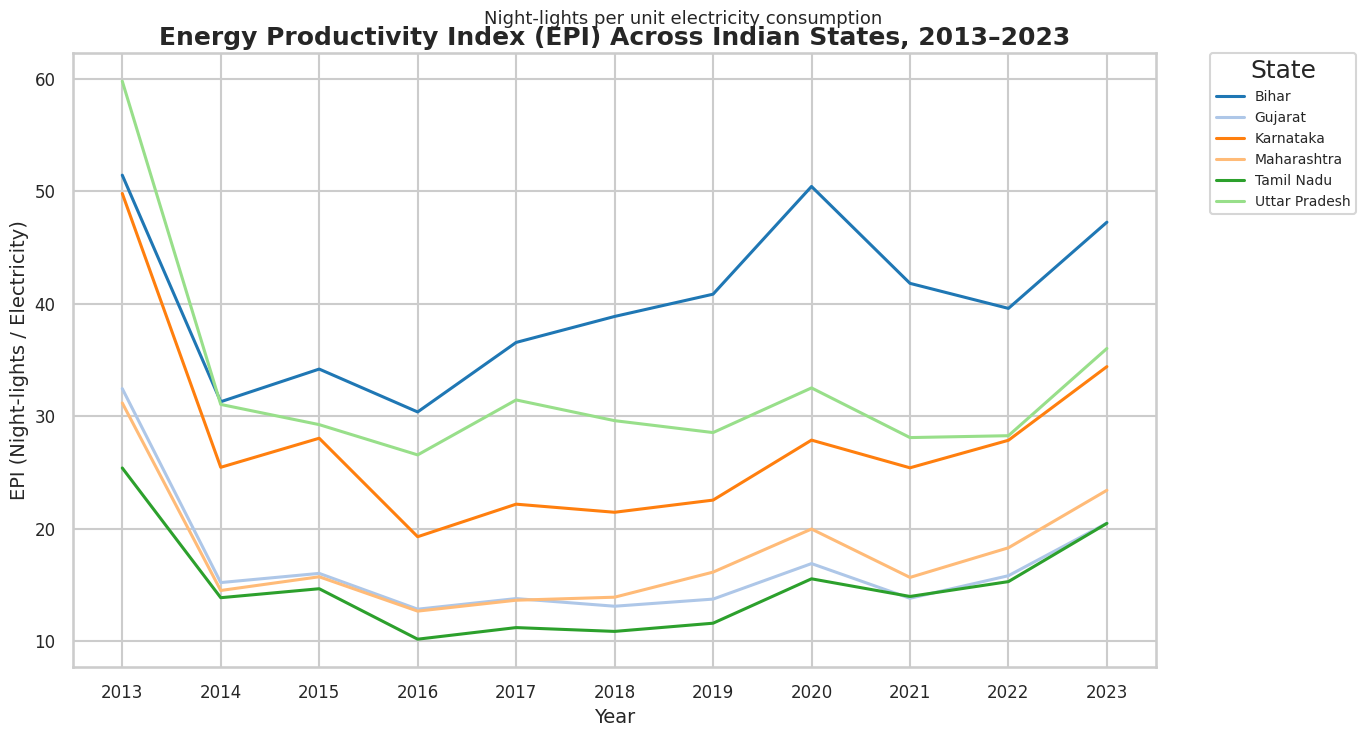

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(14, 8))

selected = ["Gujarat", "Karnataka", "Tamil Nadu", "Bihar", "Uttar Pradesh", "Maharashtra"]

df_sel = df[df["State"].isin(selected)]

sns.lineplot(data=df_sel, x="Year", y="EPI", hue="State", linewidth = 2.2, palette="tab20")


# Title and labels
plt.title("Energy Productivity Index (EPI) Across Indian States, 2013–2023",
          fontsize=18, weight="bold")
plt.suptitle("Night-lights per unit electricity consumption", fontsize=13, y=0.93)

plt.xlabel("Year", fontsize=14)
plt.ylabel("EPI (Night-lights / Electricity)", fontsize=14)

# Improve ticks
plt.xticks(df["Year"].unique(), fontsize=12)
plt.yticks(fontsize=12)

# Move legend outside
plt.legend(
    title="State",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.,
    fontsize=10
)

# Tight layout for neatness
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Pivot: rows = states, columns = years, values = EPI
epi_wide = df.pivot_table(index="State", columns="Year", values="EPI")

# Optionally fill missing values (simple choice: forward fill, then back fill)
epi_wide = epi_wide.ffill(axis=1).bfill(axis=1)
# Or: epi_wide = epi_wide.fillna(epi_wide.mean())

# Keep a copy of state names
states = epi_wide.index
X = epi_wide.values


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
k = 3  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Attach cluster labels back to a DataFrame
clusters = pd.DataFrame({
    "State": states,
    "Cluster": labels
}).sort_values("Cluster")

print(clusters)

                   State  Cluster
0         Andhra Pradesh        0
1      Arunachal Pradesh        0
2                  Assam        0
3                  Bihar        0
5           Chhattisgarh        0
15             Karnataka        0
19               Manipur        0
17        Madhya Pradesh        0
20             Meghalaya        0
30         Uttar Pradesh        0
26             Rajasthan        0
23                Odisha        0
22              Nagaland        0
29               Tripura        1
14             Jharkhand        1
4             Chandigarh        2
12      Himachal Pradesh        2
13       Jammu & Kashmir        2
10               Gujarat        2
11               Haryana        2
9                    Goa        2
8                  Delhi        2
6   Dadra & Nagar Haveli        2
7            Daman & Diu        2
21               Mizoram        2
18           Maharashtra        2
16                Kerala        2
24            Puducherry        2
27            

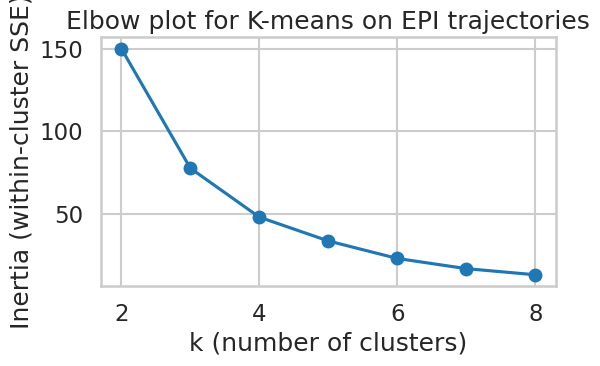

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 9)  # try k = 2..8

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow plot for K-means on EPI trajectories")
plt.tight_layout()
plt.show()


<Axes: xlabel='Year', ylabel='EPI'>

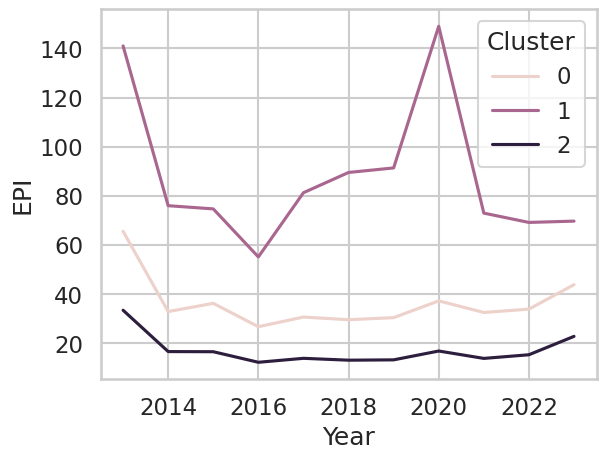

In [ ]:
df_with_clusters = df.merge(clusters, on="State", how="left")

# Example: plot average EPI by cluster over time
cluster_mean = (
    df_with_clusters
    .groupby(["Cluster", "Year"])["EPI"]
    .mean()
    .reset_index()
)

import seaborn as sns
sns.lineplot(data=cluster_mean, x="Year", y="EPI", hue="Cluster")



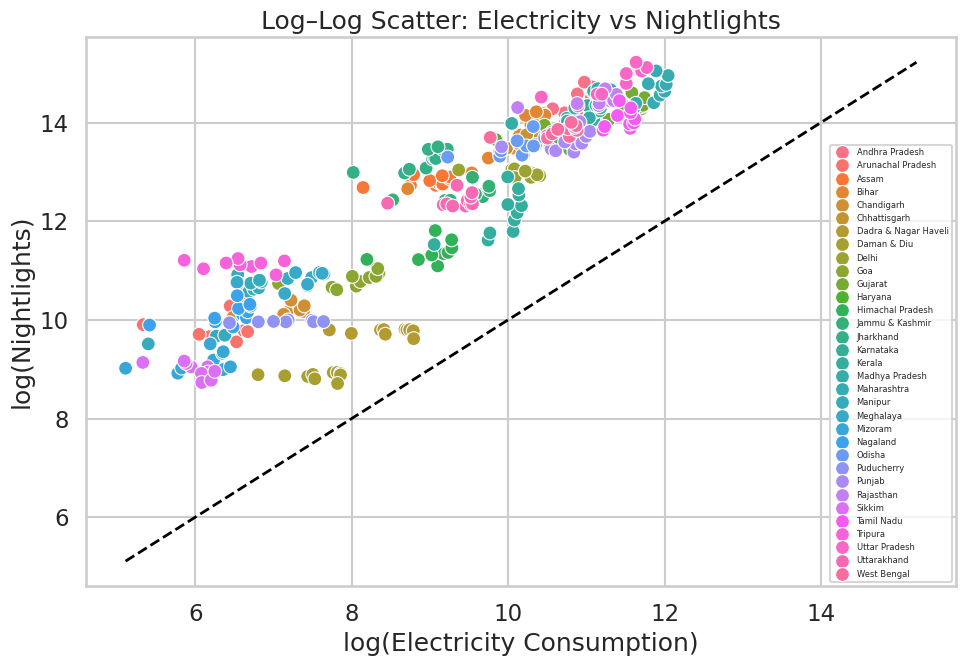

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add logged variables
df["ln_elec"] = np.log(df["Electricity_Consumption"])
df["ln_nl"] = np.log(df["Nightlights_Sum"])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="ln_elec",
    y="ln_nl",
    hue="State",
    s=100
)

# Add 1:1 line in log space (still meaningful!)
minval = min(df[["ln_elec", "ln_nl"]].min())
maxval = max(df[["ln_elec", "ln_nl"]].max())
plt.plot([minval, maxval], [minval, maxval], "k--", lw=2)

plt.xlabel("log(Electricity Consumption)")
plt.ylabel("log(Nightlights)")
plt.title("Log–Log Scatter: Electricity vs Nightlights")
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()
